In [1]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00


In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 17.3 MB/s eta 0:00:00


In [3]:
import gc
import time
import json
import os
import numpy as np
import pandas as pd
from datetime import timedelta, datetime
from collections import Counter
import matplotlib.pyplot as plt
from IPython import display
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Graph & Geometry
from torch_geometric.nn import GATv2Conv, GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph
from torch.amp import GradScaler, autocast
from safetensors.torch import save_model as save_safetensors, load_model as load_safetensors

# Molecular Processing
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, MACCSkeys

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, precision_recall_curve, auc, confusion_matrix

In [4]:
# Runtime Optimization
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"● DEVICE: {DEVICE}")
DEVICE_TYPE = DEVICE.type
# Aggressive memory management
if DEVICE_TYPE == 'cuda':
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    # Force garbage collection
    gc.collect()
    print(f"- GPU: {torch.cuda.get_device_name(0)}")
    print(f"- GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print("- ✓ Memory optimization enabled")

# Clear CUDA Cache
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    # Set Allocator Strategy to reduce fragmentation
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    print(f"- GPU Memory Freed. Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"- Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
else:
    print("-Running on CPU (No CUDA clear needed)")

TIMESTAMP = datetime.now().strftime("%d_%b_%H-%M")

# validating artifact directories:
required_directories = ['images', 'models']
for folder in required_directories:
    if not os.path.exists(folder):
        print(f"✘ Directory `{folder}/` not found \nCreating...")
        os.makedirs(folder)
    else:
        print(f"✓ Directory `{folder}/` exists")

● DEVICE: cuda
- GPU: Tesla T4
- GPU Memory: 14.56 GB
- ✓ Memory optimization enabled
- GPU Memory Freed. Allocated: 0.00 MB
- Reserved: 0.00 MB
✘ Directory `images/` not found 
Creating...
✘ Directory `models/` not found 
Creating...


In [5]:
# DDIS_DATA_PATH = 'dataset/drugdata/ddis.csv'
# DRUG_SMILE_DATA_PATH = 'dataset/drugdata/drug_smiles.csv'
DDIS_DATA_PATH = 'https://raw.githubusercontent.com/Adya-Prasad/AushadhiNet/refs/heads/main/dataset/drugdata/ddis.csv'
DRUG_SMILE_DATA_PATH = 'https://raw.githubusercontent.com/Adya-Prasad/AushadhiNet/refs/heads/main/dataset/drugdata/drug_smiles.csv'
MODEL_WEIGHT_PATH = f"models/AushadiNet_GATv2-128_{TIMESTAMP}"
MODEL_METADATA_PATH = f"models/AushadiNet_GATv2-metadata_{TIMESTAMP}"

In [6]:
# CONFIG = {
#     # MEMORY-OPTIMIZED FOR 14.56GB GPU
#     "physical_batch_size": 256,      # REDUCED: 320 → 256
#     "accumulation_steps": 8,         # INCREASED: 6 → 8 (effective batch = 2048)
#     "hidden_dim": 640,                # REDUCED: 768 → 640 (still 1.67x bigger!)
#     "n_heads": 8,                     # 640 ÷ 8 = 80 (clean)
#     "dropout": 0.35,
#     "n_gat_layers": 5,

#     # Training dynamics
#     "lr": 2e-4,
#     "weight_decay": 5e-5,
#     "epochs": 150,

#     # Loss configuration
#     "type_loss_weight": 0.3,
#     "use_focal_loss": True,
#     "use_class_weights": False,
#     "focal_alpha": 0.7,
#     "focal_gamma": 2.0,

#     # Scheduler
#     "scheduler_patience": 10,
#     "scheduler_factor": 0.5,
#     "min_lr": 1e-6,

#     # System (KEY CHANGE!)
#     "full_graph_on_gpu": True,
#     "validate_every_n_epochs": 3,

#     # Data augmentation (VERY STRONG)
#     "use_data_aug": True,
#     "edge_dropout_rate": 0.25,        # Very aggressive
#     "feature_noise": 0.025,           # Very aggressive
# }


In [7]:
CONFIG = {
    # ── Architecture (PRIMARY memory reduction) ──────────────────
    "physical_batch_size": 128,      # 256 → 128 (halves batch memory)
    "accumulation_steps": 16,        # 8 → 16 (preserves effective batch = 2048)
    "hidden_dim": 512,               # 640 → 512 (-20% embedding memory; 512÷8=64 clean)
    "n_heads": 8,                    # unchanged
    "dropout": 0.35,
    "n_gat_layers": 4,               # 5 → 4 (eliminates one layer's activation stack)

    # ── Training dynamics ────────────────────────────────────────
    "lr": 2e-4,
    "weight_decay": 5e-5,
    "epochs": 300,

    # ── Loss configuration ───────────────────────────────────────
    "type_loss_weight": 0.3,
    "use_focal_loss": True,
    "use_class_weights": False,
    "focal_alpha": 0.7,
    "focal_gamma": 2.0,

    # ── Scheduler ────────────────────────────────────────────────
    "scheduler_patience": 10,
    "scheduler_factor": 0.5,
    "min_lr": 1e-6,

    # ── System ───────────────────────────────────────────────────
    "full_graph_on_gpu": True,
    "validate_every_n_epochs": 3,
    "device_platform": "Colab",

    # ── Data augmentation (dialed back) ──────────────────────────
    "use_data_aug": True,
    "edge_dropout_rate": 0.15,       # 0.25 → 0.15 (less aggressive)
    "feature_noise": 0.01,           # 0.025 → 0.01 (less aggressive)
}

In [8]:
# Load DDI data
def read_data(ddi_path: str = DDIS_DATA_PATH, smiles_path: str = DRUG_SMILE_DATA_PATH):
    """Load raw DDI and SMILES tables from disk."""
    ddi_df = pd.read_csv(ddi_path)
    smiles_df = pd.read_csv(smiles_path)
    print("✓ Data loaded successfully")
    print("● DDI shape:", ddi_df.shape)
    unique_drugs_ddi = set(ddi_df['d1'].unique()) | set(ddi_df['d2'].unique())
    print(f"• Total DDI pairs: {len(ddi_df)}")
    print(f"• Unique drugs in DDI: {len(unique_drugs_ddi)}")
    print(f"• Drugs with SMILES: {len(smiles_df)}")
    print(f"• Drug Pair Interaction type 0: {(ddi_df['type'] == 0).sum()}")
    print(f"• Drug Pair Interaction type 7: {(ddi_df['type'] == 7).sum()}")
    print("● SMILES shape:", smiles_df.shape)
    print("● DDI columns:", ddi_df.columns.tolist())
    print("● SMILES columns:", smiles_df.columns.tolist())
    drugs_with_smiles = set(smiles_df['drug_id'].unique())
    overlap = unique_drugs_ddi & drugs_with_smiles
    print(f"• Drugs with both DDI and SMILES: {len(overlap)}")
    print(f"• Coverage: {len(overlap)/len(unique_drugs_ddi)*100:.2f}%")

    return ddi_df, smiles_df


def quick_sanity_report(ddi_df: pd.DataFrame, smiles_df: pd.DataFrame):
    """Print a compact sanity report (non‑destructive)."""
    print("\nⓘ QUICK SANITY REPORT:\n")

    # DDI
    print("[1. DDI Data: Interaction pairs]")
    print("● Total rows:", len(ddi_df))
    print("● nulls per column:", ddi_df.isnull().sum().to_dict())
    if {"d1", "d2", "type"}.issubset(ddi_df.columns):
        print("● Total interactions types:", ddi_df["type"].nunique())
        print("● Top `type` distribution (top 10):")
        print(ddi_df["type"].value_counts().head(10))

    # SMILES
    print("\n[2. SMILES Data: Molecular Structures]")
    print("● Total rows:", len(smiles_df))
    print("● Checking nulls per column?:", smiles_df.isnull().sum().to_dict())

    # Overlap
    ddi_drugs = set(ddi_df["d1"]).union(set(ddi_df["d2"]))
    smiles_drugs = set(smiles_df["drug_id"]) if "drug_id" in smiles_df.columns else set()
    overlap = ddi_drugs & smiles_drugs
    print(f"\n● Overlap: {len(overlap)}/{len(ddi_drugs)} DDI drugs have SMILES ({100*len(overlap)/len(ddi_drugs):.2f}%)")


# Load once (reused later)
ddi_df, smiles_df = read_data()
quick_sanity_report(ddi_df, smiles_df)

✓ Data loaded successfully
● DDI shape: (191808, 4)
• Total DDI pairs: 191808
• Unique drugs in DDI: 1706
• Drugs with SMILES: 1706
• Drug Pair Interaction type 0: 11
• Drug Pair Interaction type 7: 244
● SMILES shape: (1706, 2)
● DDI columns: ['d1', 'd2', 'type', 'Neg samples']
● SMILES columns: ['drug_id', 'smiles']
• Drugs with both DDI and SMILES: 1706
• Coverage: 100.00%

ⓘ QUICK SANITY REPORT:

[1. DDI Data: Interaction pairs]
● Total rows: 191808
● nulls per column: {'d1': 0, 'd2': 0, 'type': 0, 'Neg samples': 0}
● Total interactions types: 86
● Top `type` distribution (top 10):
type
48    60751
46    34360
72    23779
74     9470
59     8397
69     7786
19     6140
15     5413
3      5011
5      3160
Name: count, dtype: int64

[2. SMILES Data: Molecular Structures]
● Total rows: 1706
● Checking nulls per column?: {'drug_id': 0, 'smiles': 0}

● Overlap: 1706/1706 DDI drugs have SMILES (100.00%)


In [9]:
class DrugFeatureExtractor:
    """
    Extracting diverse 'multiviews' of the same molecule.
    View 1: Morgan FP (Detailed Substructure)
    View 2: MACCS Keys (Functional Groups)
    View 3: Physico-Chemical Properties (Global Properties)
    """
    def __init__(self):
        self.morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

    def get_features(self, smiles_df):
        view1_morgan = []
        view2_maccs = []
        view3_phys = []
        valid_ids = []

        print("● Extracting Multi-View Features...")

        for _, row in smiles_df.iterrows():
            mol = Chem.MolFromSmiles(str(row["smiles"]))
            if mol:
                # View 1: Morgan Fingerprint (1024 dim)
                fp = np.array(self.morgan_gen.GetFingerprint(mol), dtype=np.float32)

                # View 2: MACCS Keys (167 dim) - Great for functional groups
                maccs = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)

                # View 3: Physico-chemical 8 properties (8 dim) - Great for transport/metabolism
                desc = np.array([
                    Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                    Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
                    Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol),
                    Descriptors.NumAromaticRings(mol), Descriptors.FractionCSP3(mol)
                ], dtype=np.float32)

                view1_morgan.append(fp)
                view2_maccs.append(maccs)
                view3_phys.append(desc)
                valid_ids.append(row["drug_id"])

        # Stack and Normalize View 3 (since it has large values like Weight)
        v1 = np.stack(view1_morgan)
        v2 = np.stack(view2_maccs)
        v3 = np.stack(view3_phys)

        scaler = StandardScaler()
        v3 = scaler.fit_transform(v3)

        print(f"✓ Processed {len(valid_ids)} drugs.")
        print(f"  - View 1 Shape: {v1.shape}")
        print(f"  - View 2 Shape: {v2.shape}")
        print(f"  - View 3 Shape: {v3.shape}")

        return {
            "v1": torch.tensor(v1, dtype=torch.float),
            "v2": torch.tensor(v2, dtype=torch.float),
            "v3": torch.tensor(v3, dtype=torch.float),
            "ids": valid_ids
        }

# Load and Process
smiles_df = pd.read_csv(DRUG_SMILE_DATA_PATH)
extractor = DrugFeatureExtractor()
features_dict = extractor.get_features(smiles_df)

● Extracting Multi-View Features...
✓ Processed 1706 drugs.
  - View 1 Shape: (1706, 1024)
  - View 2 Shape: (1706, 167)
  - View 3 Shape: (1706, 8)


In [10]:
class GraphBuilder:
    def __init__(self, ddi_path, feature_dict):
        self.ddi_df = pd.read_csv(ddi_path)
        self.feats = feature_dict
        self.drug_map = {d: i for i, d in enumerate(feature_dict['ids'])}
        self.idx_map = {i: d for d, i in self.drug_map.items()}
        self.type_enc = LabelEncoder()

    def build(self):
        # Map Edges
        pos_src, pos_dst, pos_types = [], [], []
        neg_src, neg_dst = [], []

        print("● Building DDI Graph Topology...")
        for _, row in self.ddi_df.iterrows():
            if row['d1'] in self.drug_map and row['d2'] in self.drug_map:
                u, v = self.drug_map[row['d1']], self.drug_map[row['d2']]

                # Bidirectional Positive Edge
                # Because If A interacts with B, then B interacts with A
                pos_src.extend([u, v])
                pos_dst.extend([v, u])
                pos_types.extend([row['type'], row['type']])

                # Negative Edge Handling: "DRUGID$t" or "DRUGID$h" -> extract DRUGID only
                if isinstance(row['Neg samples'], str):
                    neg_raw = row['Neg samples'].strip().split('$')[0]
                    if neg_raw and neg_raw in self.drug_map:
                        w = self.drug_map[neg_raw]
                        neg_src.extend([u, w])
                        neg_dst.extend([w, u])

        # Convert to Tensors
        pos_edge_index = torch.tensor([pos_src, pos_dst], dtype=torch.long)
        neg_edge_index = torch.tensor([neg_src, neg_dst], dtype=torch.long)

        # Combine for processing
        full_edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)

        # Label Encoding: Encode Types
        # Original: ["metabolism", "toxicity", "bleeding"]
        # Encoded:  [48, 46, 19]
        y_types_enc = self.type_enc.fit_transform(pos_types)

        # Create Labels
        # Binary: 1 for pos, 0 for neg
        y_binary = torch.cat([torch.ones(pos_edge_index.shape[1]), torch.zeros(neg_edge_index.shape[1])]).long()
        # Type: Encoded for pos, -1 for neg
        y_type = torch.cat([torch.tensor(y_types_enc), torch.full((neg_edge_index.shape[1],), -1)]).long()

        return {
            "x_v1": self.feats['v1'],
            "x_v2": self.feats['v2'],
            "x_v3": self.feats['v3'],
            "edge_index": full_edge_index,
            "y_binary": y_binary,
            "y_type": y_type,
            "n_types": len(self.type_enc.classes_),
            "encoder": self.type_enc,
            "drug_map": self.drug_map
        }

    def create_stratified_split(self, graph):
        # Stratified Split based on Binary Labels to ensure Negatives are balanced in Train/Val
        print("● Creating Stratified Splits (TDCommons Standard)...")
        n_edges = graph['edge_index'].shape[1]
        indices = np.arange(n_edges)

        train_idx, temp_idx = train_test_split(
            indices, test_size=0.3, stratify=graph['y_binary'], random_state=42
        )
        val_idx, test_idx = train_test_split(
            temp_idx, test_size=0.5, stratify=graph['y_binary'][temp_idx], random_state=42
        )

        # Create Boolean Masks
        for name, idx in zip(['train', 'val', 'test'], [train_idx, val_idx, test_idx]):
            mask = torch.zeros(n_edges, dtype=torch.bool)
            mask[idx] = True
            graph[f'{name}_mask'] = mask

        print(f"  - Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
        return graph

builder = GraphBuilder(DDIS_DATA_PATH, features_dict)
graph_data = builder.build()
graph = builder.create_stratified_split(graph_data)

● Building DDI Graph Topology...
● Creating Stratified Splits (TDCommons Standard)...
  - Train: 537062 | Val: 115085 | Test: 115085


In [11]:
class DDIDataAugmenter:
    """
    Augment training data to improve generalization:
    1. Edge dropout (random edge masking)
    2. Feature perturbation
    3. Hard negative mining
    """
    @staticmethod
    def augment_graph_training(graph, edge_dropout=0.1, feature_noise=0.01):
        """
        Apply augmentation during training epoch.
        """
        # Edge dropout: Randomly remove edges from adjacency
        if edge_dropout > 0:
            mask = torch.rand(graph['edge_index'].shape[1]) > edge_dropout
            aug_edge_index = graph['edge_index'][:, mask]
        else:
            aug_edge_index = graph['edge_index']

        # Feature noise: Add small Gaussian noise
        if feature_noise > 0:
            aug_x_v1 = graph['x_v1'] + torch.randn_like(graph['x_v1']) * feature_noise
            aug_x_v2 = graph['x_v2'] + torch.randn_like(graph['x_v2']) * feature_noise
            aug_x_v3 = graph['x_v3'] + torch.randn_like(graph['x_v3']) * feature_noise
        else:
            aug_x_v1, aug_x_v2, aug_x_v3 = graph['x_v1'], graph['x_v2'], graph['x_v3']

        return {
            'edge_index': aug_edge_index,
            'x_v1': aug_x_v1,
            'x_v2': aug_x_v2,
            'x_v3': aug_x_v3
        }

In [12]:
def plot_training_dashboard(history, config):
    """
    Plot training metrics dashboard showing ONLY validated epochs.
    Removes flat lines by filtering out epochs where validation was skipped.

    Parameters:
    - history: Dictionary with training metrics
    - config: Configuration dictionary with validate_every_n_epochs
    """
    display.clear_output(wait=True)

    total_epochs = len(history['train_loss'])
    validate_every = config.get('validate_every_n_epochs', 1)

    # Determine which epochs had actual validation
    validated_epochs = []
    for epoch in range(1, total_epochs + 1):
        do_validate = (epoch % validate_every == 0) or (epoch == total_epochs)
        if do_validate:
            validated_epochs.append(epoch)

    # Extract metrics only for validated epochs
    # Note: epoch indices are 0-based in lists, but 1-based in display
    validated_indices = [e - 1 for e in validated_epochs]  # Convert to 0-based

    train_loss_validated = [history['train_loss'][i] for i in validated_indices]
    val_acc_validated = [history['val_acc'][i] for i in validated_indices]
    val_f1_validated = [history['val_f1'][i] for i in validated_indices]
    val_precision_validated = [history['val_precision'][i] for i in validated_indices]
    val_recall_validated = [history['val_recall'][i] for i in validated_indices]

    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Training Metrics Dashboard (Validated Epochs Only)\nValidation Frequency: Every {validate_every} epoch(s)",
                 fontsize=16, fontweight='bold')

    # 1 Training Loss
    axes[0, 0].plot(validated_epochs, train_loss_validated,
                    color='royalblue', marker='o', markersize=5, linewidth=2, label='Train Loss')
    axes[0, 0].set_title("Training Loss", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(alpha=0.3, linestyle='--')
    axes[0, 0].legend()

    # Add value annotations for key points
    if len(train_loss_validated) > 0:
        axes[0, 0].annotate(f'{train_loss_validated[-1]:.4f}',
                           xy=(validated_epochs[-1], train_loss_validated[-1]),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)

    # 2️ Validation Accuracy
    axes[0, 1].plot(validated_epochs, val_acc_validated,
                    color='seagreen', marker='o', markersize=5, linewidth=2, label='Val Accuracy')
    axes[0, 1].set_title("Validation Accuracy", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(alpha=0.3, linestyle='--')
    axes[0, 1].legend()

    # Add best accuracy marker
    if len(val_acc_validated) > 0:
        best_acc_idx = val_acc_validated.index(max(val_acc_validated))
        axes[0, 1].scatter([validated_epochs[best_acc_idx]], [val_acc_validated[best_acc_idx]],
                          color='red', s=100, zorder=5, marker='*', label='Best')
        axes[0, 1].annotate(f'Best: {val_acc_validated[best_acc_idx]:.4f}',
                           xy=(validated_epochs[best_acc_idx], val_acc_validated[best_acc_idx]),
                           xytext=(5, -15), textcoords='offset points', fontsize=9, color='red')
        axes[0, 1].legend()

    # 3 Validation F1 Score
    axes[1, 0].plot(validated_epochs, val_f1_validated,
                    color='darkorange', marker='o', markersize=5, linewidth=2, label='Val F1')
    axes[1, 0].set_title("Validation F1-Score", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("F1-Score")
    axes[1, 0].grid(alpha=0.3, linestyle='--')
    axes[1, 0].legend()

    # Add best F1 marker
    if len(val_f1_validated) > 0:
        best_f1_idx = val_f1_validated.index(max(val_f1_validated))
        axes[1, 0].scatter([validated_epochs[best_f1_idx]], [val_f1_validated[best_f1_idx]],
                          color='red', s=100, zorder=5, marker='*', label='Best')
        axes[1, 0].annotate(f'Best: {val_f1_validated[best_f1_idx]:.4f}',
                           xy=(validated_epochs[best_f1_idx], val_f1_validated[best_f1_idx]),
                           xytext=(5, -15), textcoords='offset points', fontsize=9, color='red')
        axes[1, 0].legend()

    # 4 Validation Precision & Recall (Combined)
    axes[1, 1].plot(validated_epochs, val_precision_validated,
                    color='crimson', marker='o', markersize=5, linewidth=2, label='Precision')
    axes[1, 1].plot(validated_epochs, val_recall_validated,
                    color='purple', marker='s', markersize=5, linewidth=2, label='Recall')
    axes[1, 1].set_title("Validation Precision & Recall", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Score")
    axes[1, 1].grid(alpha=0.3, linestyle='--')
    axes[1, 1].legend()

    plt.tight_layout()
    display.display(plt.gcf())

    plt.savefig(f"images/AushadiNet_training_dashboard{TIMESTAMP}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)  # Prevent memory leak

In [13]:
class FeatureAttentionLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.atten = nn.Linear(dim, 1)

    def forward(self, v1, v2, v3):
        stack = torch.stack([v1, v2, v3], dim=1)
        scores = F.softmax(self.atten(stack), dim=1)
        fused = torch.sum(stack * scores, dim=1)
        return fused, scores

class GATv2NN(nn.Module):
    """
    Dynamic GAT model with configurable number of layers.

    Improvements:
    1. Residual connections for better gradient flow
    2. Layer normalization for training stability
    3. Dynamic layer creation based on n_gat_layers parameter
    """
    def __init__(self, dims, hidden_dim, n_heads, n_types, dropout=0.3, n_gat_layers=3):
        super().__init__()

        # Validate n_heads divides hidden_dim evenly
        if hidden_dim % n_heads != 0:
            raise ValueError(f"hidden_dim ({hidden_dim}) must be divisible by n_heads ({n_heads})")

        # View Projectors with BatchNorm
        self.proj_v1 = nn.Sequential(
            nn.Linear(dims['v1'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        self.proj_v2 = nn.Sequential(
            nn.Linear(dims['v2'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        self.proj_v3 = nn.Sequential(
            nn.Linear(dims['v3'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )

        # Feature Attention (multi-view fusion)
        self.feat_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, 1)
        )

        # Dynamic GAT Layers with residual connections
        # Creates n_gat_layers GAT layers automatically based on config
        self.n_gat_layers = n_gat_layers
        self.gat_layers = nn.ModuleList()
        self.norm_layers = nn.ModuleList()

        for i in range(n_gat_layers):
            if i == 0:
                # First layer: multi-head with concatenation
                # Output: hidden_dim (because heads * out_channels = n_heads * (hidden_dim // n_heads) = hidden_dim)
                gat = GATv2Conv(
                    hidden_dim,
                    hidden_dim // n_heads,  # Per-head dimension
                    heads=n_heads,
                    concat=True,  # Concatenate heads
                    dropout=dropout
                )
            else:
                # Subsequent layers: single head for efficiency
                # Output: hidden_dim
                gat = GATv2Conv(
                    hidden_dim,
                    hidden_dim,
                    heads=1,
                    concat=False,
                    dropout=dropout
                )

            self.gat_layers.append(gat)
            self.norm_layers.append(nn.LayerNorm(hidden_dim))

        # Edge Classifier with deeper network
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
        )

        self.head_bin = nn.Linear(hidden_dim // 2, 2)
        self.head_type = nn.Linear(hidden_dim // 2, n_types)

        self.dropout = dropout

        print(f"✓ Model Initialized: {n_gat_layers} GAT layers, {hidden_dim}D hidden, {n_heads} heads\n")

    def get_node_embeddings(self, x_v1, x_v2, x_v3, edge_index):
        """
        Full-graph forward pass with dynamic GAT layers.

        Flow:
        1. Project each view to hidden_dim
        2. Fuse views with attention
        3. Apply n_gat_layers GAT layers with residual connections
        4. Return final node embeddings
        """
        # Project each view to hidden_dim
        h1 = self.proj_v1(x_v1)
        h2 = self.proj_v2(x_v2)
        h3 = self.proj_v3(x_v3)

        # Multi-view attention fusion
        stack = torch.stack([h1, h2, h3], dim=1)  # (N, 3, hidden_dim)
        scores = F.softmax(self.feat_attention(stack), dim=1)
        h_fused = torch.sum(stack * scores, dim=1)  # (N, hidden_dim)

        # Apply GAT layers dynamically with PROPER residual connections
        h = h_fused
        for i, (gat, norm) in enumerate(zip(self.gat_layers, self.norm_layers)):
            # Save input for residual
            h_input = h

            # GAT convolution
            h_gat = gat(h, edge_index)

            # Residual connection: connect to PREVIOUS layer (not always h_fused)
            h = norm(h_gat + h_input)  # ← FIXED: h_input instead of h_fused

            # Activation after normalization
            h = F.elu(h)

        return h  # (N, hidden_dim)

    def forward_edges_from_emb(self, node_emb, edge_label_index):
        """
        Edge classification from node embeddings.

        Args:
            node_emb: Node embeddings (N, hidden_dim)
            edge_label_index: Edge indices (2, E)

        Returns:
            Binary predictions (E, 2) and Type predictions (E, n_types)
        """
        src, dst = edge_label_index[0], edge_label_index[1]

        # Concatenate source and destination node embeddings
        edge_feat = torch.cat([node_emb[src], node_emb[dst]], dim=-1)  # (E, hidden_dim * 2)

        # Shared edge encoder
        shared = self.edge_encoder(edge_feat)  # (E, hidden_dim // 2)

        # Two prediction heads
        return self.head_bin(shared), self.head_type(shared)

    def forward(self, x_v1, x_v2, x_v3, edge_index, edge_label_index):
        """Full forward pass (for inference)."""
        node_emb = self.get_node_embeddings(x_v1, x_v2, x_v3, edge_index)
        return self.forward_edges_from_emb(node_emb, edge_label_index)

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.7, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

In [14]:
class BestModelTracker:
    """
    Smart model saving with 3 rules:
    1. Only save if improvement > min_delta (ignore noise)
    2. Only keep 1 file (delete old best before saving new)
    3. Save in safetensors format
    """
    def __init__(self, save_dir='models', min_delta=0.005, metric_name='f1'):
        self.save_dir = save_dir
        self.min_delta = min_delta
        self.metric_name = metric_name
        self.best_score = 0.0
        self.best_path = None
        self.save_count = 0
        os.makedirs(save_dir, exist_ok=True)

    def update(self, model, score, epoch):
        """
        Call after each validation.
        Returns True if model was saved, False if improvement was too small.
        """
        improvement = score - self.best_score

        if improvement > self.min_delta:
            # Delete old best model file
            if self.best_path and os.path.exists(self.best_path):
                os.remove(self.best_path) # removing old checkpoint
            # Save new best
            self.best_score = score
            filename = f'AushadiNet_GATv2_F1-{score:.4f}_ep-{epoch}.safetensors'
            self.best_path = os.path.join(self.save_dir, filename)

            # Get base model (handles torch.compile wrapper)
            base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            save_safetensors(base_model, self.best_path)

            self.save_count += 1
            print(f"[✓] New best model found! At epoch {epoch} with F1: {score:.4f} and improvement of {improvement:.4f}")
            return True

        return False

    def load_best(self, model):
        """Load the best saved model back into model."""
        if self.best_path and os.path.exists(self.best_path):
            base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            load_safetensors(base_model, self.best_path)
            print(f"(✓) Loaded best model: {os.path.basename(self.best_path)}")
            print(f"   Best {self.metric_name}: {self.best_score:.4f}")
        else:
            print("(✘) No saved model found.")
        return model

    def summary(self):
        print(f"\n➜ Model Saving Summary:")
        print(f"- Total progressive best models: {self.save_count}")
        print(f"- Best {self.metric_name}: {self.best_score:.4f}")
        print(f"- Saved at: {self.best_path}")

In [15]:
def train_model(graph, config, model, device='cuda'):
    """
    FIXED TRAINING: GNN trains via proxy gradient trick.
    - Edge MLP: trains every accumulation step (fast)
    - GNN encoder: trains once per epoch via accumulated gradients
    """
    physical_batch = config["physical_batch_size"]
    accum_steps = config["accumulation_steps"]
    type_w = config.get("type_loss_weight", 0.5)
    validate_every = config.get("validate_every_n_epochs", 2)

    START_TIME = time.perf_counter()
    print(f"MODEL TRAINING STARTING AT: {time.strftime('%H:%M:%S', time.localtime())}...\n")

    # Data Loaders
    train_edges = graph['edge_index'][:, graph['train_mask']]
    train_labels = torch.stack([
        graph['y_binary'][graph['train_mask']],
        graph['y_type'][graph['train_mask']]
    ], dim=1)
    val_edges = graph['edge_index'][:, graph['val_mask']]
    val_labels = torch.stack([
        graph['y_binary'][graph['val_mask']],
        graph['y_type'][graph['val_mask']]
    ], dim=1)

    train_loader = DataLoader(
        TensorDataset(train_edges.t(), train_labels),
        batch_size=physical_batch, shuffle=True,
        pin_memory=True, num_workers=2, persistent_workers=True
    )
    val_loader = DataLoader(
        TensorDataset(val_edges.t(), val_labels),
        batch_size=physical_batch * 2, shuffle=False,
        pin_memory=True, num_workers=2
    )

    # Loss Configuration
    y_train_bin = graph['y_binary'][graph['train_mask']].numpy()
    n_pos = int((y_train_bin == 1).sum())
    n_neg = int((y_train_bin == 0).sum())

    use_focal   = config.get("use_focal_loss", False)
    use_weights = config.get("use_class_weights", False)

    if use_focal and use_weights:
        print("⚠︎  Warning: Both focal loss and class weights enabled. Using Focal Loss (takes priority).")
        use_weights = False

    if use_focal:
        crit_bin = FocalLoss(
            alpha=config.get("focal_alpha", 0.7),
            gamma=config.get("focal_gamma", 2.0)
        )
        print(f"✓ Loss: FocalLoss(alpha={config.get('focal_alpha', 0.7)}, gamma={config.get('focal_gamma', 2.0)})")

    elif use_weights and n_pos > 0 and n_neg > 0:
        w_pos = (n_pos + n_neg) / (2.0 * n_pos)
        w_neg = (n_pos + n_neg) / (2.0 * n_neg)
        class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)
        crit_bin = nn.CrossEntropyLoss(weight=class_weights)
        print(f"✓ Loss: CrossEntropyLoss | Class weights: neg={w_neg:.3f}, pos={w_pos:.3f}")

    else:
        crit_bin = nn.CrossEntropyLoss()
        print("✓ Loss: CrossEntropyLoss (unweighted)")

    crit_type = nn.CrossEntropyLoss(ignore_index=-1)

    # Move graph to GPU
    full_adj = graph['edge_index'].to(device)
    x_v1 = graph['x_v1'].to(device)
    x_v2 = graph['x_v2'].to(device)
    x_v3 = graph['x_v3'].to(device)

    # TWO SEPARATE OPTIMIZERS
    gnn_param_names = ['proj_v1', 'proj_v2', 'proj_v3', 'feat_attention',
                       'gat_layers', 'norm_layers']
    edge_param_names = ['edge_encoder', 'head_bin', 'head_type']

    base_model = model._orig_mod if hasattr(model, '_orig_mod') else model

    gnn_params  = [p for n, p in base_model.named_parameters()
                   if any(n.startswith(x) for x in gnn_param_names)]
    edge_params = [p for n, p in base_model.named_parameters()
                   if any(n.startswith(x) for x in edge_param_names)]

    print(f"- GNN params:  {sum(p.numel() for p in gnn_params):,}")
    print(f"- Edge params: {sum(p.numel() for p in edge_params):,}")

    gnn_optimizer  = Adam(gnn_params,  lr=config['lr'], weight_decay=config.get('weight_decay', 1e-4))
    edge_optimizer = Adam(edge_params, lr=config['lr'], weight_decay=config.get('weight_decay', 1e-4))

    edge_scaler = GradScaler()

    gnn_scheduler = lr_scheduler.ReduceLROnPlateau(
        gnn_optimizer, mode='max',
        patience=config.get('scheduler_patience', 4),
        factor=config.get('scheduler_factor', 0.5)
    )
    edge_scheduler = lr_scheduler.ReduceLROnPlateau(
        edge_optimizer, mode='max',
        patience=config.get('scheduler_patience', 4),
        factor=config.get('scheduler_factor', 0.5)
    )

    history = {
        'train_loss': [], 'val_acc': [], 'val_f1': [],
        'val_precision': [], 'val_recall': [], 'training_duration': []
    }

    print(f"\n{'—'*75}")
    print(f"{'Epoch':<6} | {'Train Loss':<11} | {'Val Acc':<8} | {'Val F1':<8} | {'Val P':<8} | {'Val R':<8} | {'Time':<8}")
    print(f"{'—'*75}")

    best_f1 = 0.0
    tracker = BestModelTracker(save_dir='models', min_delta=0.005, metric_name='f1')
    use_aug = config.get("use_data_aug", False)

    for epoch in range(1, config['epochs'] + 1):
        epoch_start = time.time()
        model.train()

        # DATA AUGMENTATION
        # =================
        if use_aug and (config.get('edge_dropout_rate', 0) > 0 or config.get('feature_noise', 0) > 0):
            aug_data = DDIDataAugmenter.augment_graph_training(
                {'edge_index': full_adj, 'x_v1': x_v1, 'x_v2': x_v2, 'x_v3': x_v3},
                edge_dropout=config.get('edge_dropout_rate', 0),
                feature_noise=config.get('feature_noise', 0)
            )
            aug_adj   = aug_data['edge_index']
            aug_x_v1  = aug_data['x_v1']
            aug_x_v2  = aug_data['x_v2']
            aug_x_v3  = aug_data['x_v3']
        else:
            aug_adj              = full_adj
            aug_x_v1, aug_x_v2, aug_x_v3 = x_v1, x_v2, x_v3

        # PHASE 1: GNN node embeddings (with gradient tracking)
        # ======================================================
        gnn_optimizer.zero_grad()
        with autocast(device.type):
            node_emb = model.get_node_embeddings(aug_x_v1, aug_x_v2, aug_x_v3, aug_adj)

        node_emb_proxy = node_emb.detach().requires_grad_(True)

        # PHASE 2: Train Edge MLP via proxy embeddings
        # =============================================
        edge_optimizer.zero_grad()
        total_loss = 0.0

        for i, (batch_edges, batch_labels) in enumerate(train_loader):
            batch_edges = batch_edges.t().to(device, non_blocking=True)
            y_bin  = batch_labels[:, 0].to(device, non_blocking=True)
            y_type = batch_labels[:, 1].to(device, non_blocking=True)

            with autocast(device.type):
                pred_bin, pred_type = model.forward_edges_from_emb(node_emb_proxy, batch_edges)
                loss = (crit_bin(pred_bin, y_bin) +
                        type_w * crit_type(pred_type, y_type)) / accum_steps

            edge_scaler.scale(loss).backward()
            total_loss += loss.item() * accum_steps

            if (i + 1) % accum_steps == 0:
                edge_scaler.step(edge_optimizer)
                edge_scaler.update()
                edge_optimizer.zero_grad()

        train_loss = total_loss / len(train_loader)
        history['train_loss'].append(train_loss)

        # PHASE 3: Propagate gradients back through GNN
        # ==============================================
        if node_emb_proxy.grad is not None:
            scale = edge_scaler.get_scale()
            unscaled_grad = node_emb_proxy.grad / scale if scale != 0 else node_emb_proxy.grad
            node_emb.backward(unscaled_grad)
            torch.nn.utils.clip_grad_norm_(gnn_params, max_norm=1.0)
            gnn_optimizer.step()
        gnn_optimizer.zero_grad()

        # Explicitly release augmented tensors
        # Each epoch, augmentation creates NEW GPU tensors (via torch.randn_like).
        # Without del, they linger in memory until Python's GC decides to collect
        # them, which causes fragmentation and eventual OOM on long runs.
        # We only delete if augmentation was active (i.e. they're distinct objects
        # from x_v1/x_v2/x_v3 — deleting aliases of the originals is a no-op but
        # the guard makes the intent explicit).
        if use_aug:
            del aug_adj, aug_x_v1, aug_x_v2, aug_x_v3
        # Validation
        # ==========
        do_validate = (epoch % validate_every == 0) or (epoch == config['epochs'])

        if do_validate:
            model.eval()
            all_preds, all_trues = [], []

            with torch.no_grad():
                with autocast(device.type):
                    node_emb_val = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)
                for batch_edges, batch_labels in val_loader:
                    batch_edges = batch_edges.t().to(device, non_blocking=True)
                    p_bin, _ = model.forward_edges_from_emb(node_emb_val, batch_edges)
                    all_preds.extend(torch.argmax(p_bin, dim=1).cpu().numpy())
                    all_trues.extend(batch_labels[:, 0].numpy())

            all_trues = np.array(all_trues)
            all_preds = np.array(all_preds)

            val_acc  = accuracy_score(all_trues, all_preds)
            val_f1   = f1_score(all_trues, all_preds, zero_division=0)
            val_prec = precision_score(all_trues, all_preds, zero_division=0)
            val_rec  = recall_score(all_trues, all_preds, zero_division=0)

            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)
            history['val_precision'].append(val_prec)
            history['val_recall'].append(val_rec)

            gnn_scheduler.step(val_f1)
            edge_scheduler.step(val_f1)

            tracker.update(model, val_f1, epoch)
            if val_f1 > best_f1:
                best_f1 = val_f1

            epoch_time = time.time() - epoch_start
            print(f"{epoch:>4}   | {train_loss:>9.4f}   | {val_acc:>6.4f}  | {val_f1:>6.4f}  | {val_prec:>6.4f}  | {val_rec:>6.4f}  | {epoch_time:>5.1f}s")
        else:
            for k in ['val_acc', 'val_f1', 'val_precision', 'val_recall']:
                history[k].append(history[k][-1] if history[k] else 0.0)

        torch.cuda.empty_cache()

    tracker.summary()
    model = tracker.load_best(model)

    END_TIME = time.perf_counter()
    formatted_time = str(timedelta(seconds=int(END_TIME - START_TIME)))
    history['training_duration'].append(formatted_time)

    print(f"{'—'*75}")
    print(f"(✓) {config['epochs']} Epochs completed in {history['training_duration']} "
          f"at {time.strftime('%H:%M:%S', time.localtime())} with best Val F1: {best_f1:.4f}")

    return model, history, tracker

In [16]:
# Step 3: Initialize model
model = GATv2NN(
    dims={'v1': 1024, 'v2': 167, 'v3': 8},
    hidden_dim=CONFIG['hidden_dim'],
    n_heads=CONFIG['n_heads'],
    n_types=graph['n_types'],
    dropout=CONFIG['dropout'],
    n_gat_layers=CONFIG['n_gat_layers']
).to(DEVICE)

# Step 4: Check memory
print("\n📊 Memory Status:")
allocated = torch.cuda.memory_allocated() / 1024**3
total = torch.cuda.get_device_properties(0).total_memory / 1024**3
free = total - allocated
print(f"  Allocated: {allocated:.2f} GB")
print(f"  Free: {free:.2f} GB")
print(f"  Total: {total:.2f} GB")

# Step 5: Train
trained_model, training_history, tracker = train_model(
    graph,
    CONFIG,
    model,
    device=DEVICE
)


✓ Model Initialized: 4 GAT layers, 512D hidden, 8 heads


📊 Memory Status:
  Allocated: 0.01 GB
  Free: 14.55 GB
  Total: 14.56 GB
MODEL TRAINING STARTING AT: 12:09:12...

✓ Loss: FocalLoss(alpha=0.7, gamma=2.0)
- GNN params:  2,793,729
- Edge params: 680,280

———————————————————————————————————————————————————————————————————————————
Epoch  | Train Loss  | Val Acc  | Val F1   | Val P    | Val R    | Time    
———————————————————————————————————————————————————————————————————————————
[✓] New best model found! At epoch 3 with F1: 0.6660 and improvement of 0.6660
   3   |    0.4522   | 0.4995  | 0.6660  | 0.4997  | 0.9981  |  24.5s
   6   |    0.3328   | 0.5063  | 0.6685  | 0.5032  | 0.9957  |  24.7s
   9   |    0.2801   | 0.5035  | 0.6679  | 0.5018  | 0.9985  |  24.6s
  12   |    0.2435   | 0.5020  | 0.6667  | 0.5010  | 0.9962  |  24.7s
[✓] New best model found! At epoch 15 with F1: 0.6735 and improvement of 0.0074
  15   |    0.2184   | 0.5238  | 0.6735  | 0.5124  | 0.9821  |  24.6s
[✓

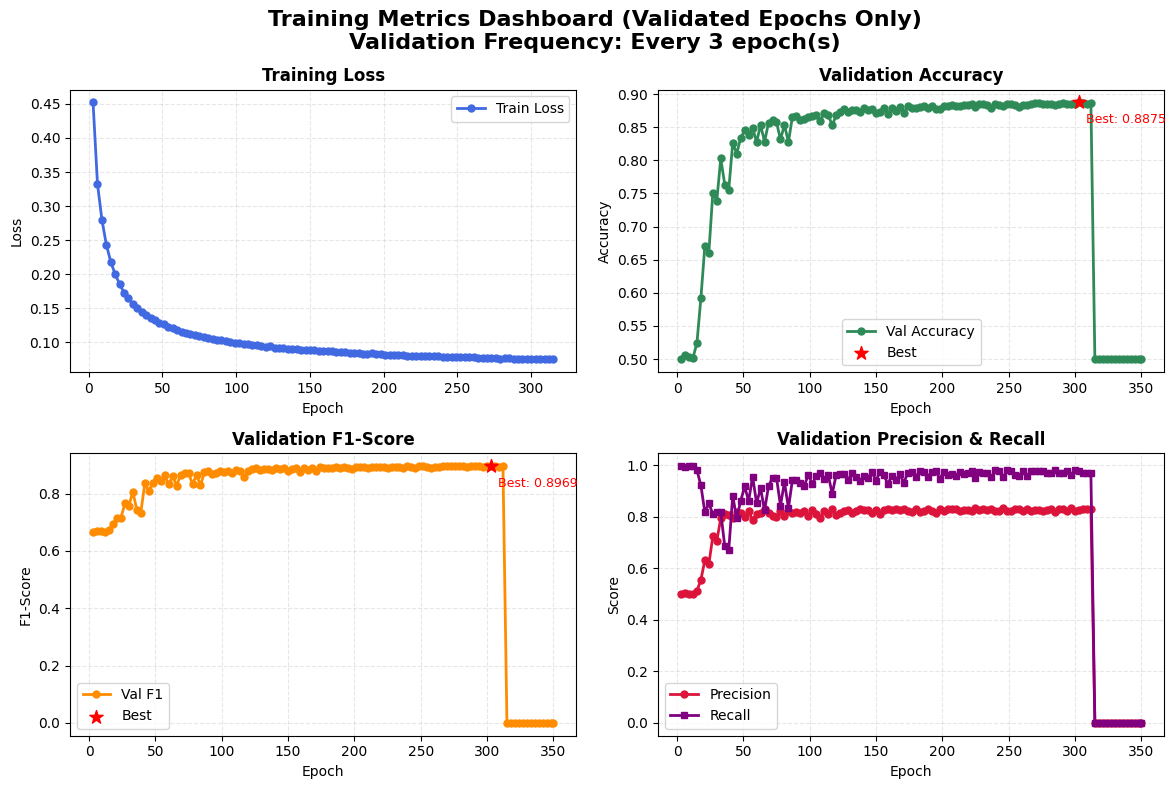

In [18]:
plot_training_dashboard(training_history, CONFIG)

In [19]:
# Cell: Complete Test Set Evaluation
def training_evaluation(model, graph, batch_size=512):
    """
    Complete test set evaluation with:
    - Binary classification metrics
    - Type classification metrics
    - Confusion matrix
    - Per-class performance
    """
    print("COMPREHENSIVE TEST SET EVALUATION")
    print("—"*33, "\n")

    model.eval()
    test_edges = graph['edge_index'][:, graph['test_mask']]
    test_labels_bin = graph['y_binary'][graph['test_mask']]
    test_labels_type = graph['y_type'][graph['test_mask']]

    test_loader = DataLoader(
        TensorDataset(test_edges.t(),
                     torch.stack([test_labels_bin, test_labels_type], dim=1)),
        batch_size=batch_size, shuffle=False
    )

    full_adj = graph['edge_index'].to(DEVICE)
    x_v1, x_v2, x_v3 = graph['x_v1'].to(DEVICE), graph['x_v2'].to(DEVICE), graph['x_v3'].to(DEVICE)

    all_preds_bin, all_probs_bin, all_trues_bin = [], [], []
    all_preds_type, all_trues_type = [], []

    with torch.no_grad():
        with autocast(DEVICE_TYPE):
            node_emb = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)

        for batch_edges, batch_labels in test_loader:
            batch_edges = batch_edges.t().to(DEVICE)
            p_bin, p_type = model.forward_edges_from_emb(node_emb, batch_edges)

            # Binary predictions
            probs = torch.softmax(p_bin, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(p_bin, dim=1).cpu().numpy()
            all_preds_bin.extend(preds)
            all_probs_bin.extend(probs)
            all_trues_bin.extend(batch_labels[:, 0].numpy())

            # Type predictions (only for positive samples)
            type_preds = torch.argmax(p_type, dim=1).cpu().numpy()
            all_preds_type.extend(type_preds)
            all_trues_type.extend(batch_labels[:, 1].numpy())

    # Convert to arrays
    y_true_bin = np.array(all_trues_bin)
    y_pred_bin = np.array(all_preds_bin)
    y_prob_bin = np.array(all_probs_bin)
    y_true_type = np.array(all_trues_type)
    y_pred_type = np.array(all_preds_type)

    # 1. BINARY CLASSIFICATION
    print("1. BINARY CLASSIFICATION (Interaction: Yes/No)")
    print(f"{'-'*46}")

    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true_bin, y_prob_bin)
    except:
        roc_auc = float('nan')

    print(f"• Accuracy:      {acc:.4f}")
    print(f"• F1 Score:      {f1:.4f} ")
    print(f"• Precision:     {prec:.4f}")
    print(f"• Recall:        {rec:.4f}")
    print(f"• ROC-AUC:       {roc_auc:.4f}")

    # Confusion Matrix

    cm = confusion_matrix(y_true_bin, y_pred_bin)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n1.2 CONFUSION MATRIX:")
    print(f"-"*61)
    print(f"| {' '*16}| Predicted: No Int | Predicted: Interact |")
    print(f"| Actual No Int   | {tn:6d}{' '*12}|{fp:6d} {' '*14}|")
    print(f"| Actual Interact | {fn:6d}{' '*12}|{tp:6d} {' '*14}|")
    print(f"-"*61)
    print(f"• True Positives:  {tp:6d}  (Correctly detected interactions)")
    print(f"• False Positives: {fp:6d}  (False alarms - Incorrectly predicted as safe)")
    print(f"• False Negatives: {fn:6d}  (⚠ CRITICAL: Missed interactions!)")
    print(f"• True Negatives:  {tn:6d}  (Correctly identified safe)")

    # 2. INTERACTION TYPES CLASSIFICATION
    print("\n\n2. TYPE CLASSIFICATION (Which interaction type?)")
    print(f"{'-'*48}")

    # Filter to only positive samples (where type is meaningful)
    pos_mask = y_true_bin == 1
    if pos_mask.sum() > 0:
        y_true_type_pos = y_true_type[pos_mask]
        y_pred_type_pos = y_pred_type[pos_mask]

        type_acc = accuracy_score(y_true_type_pos, y_pred_type_pos)
        type_f1 = f1_score(y_true_type_pos, y_pred_type_pos, average='weighted', zero_division=0)

        print(f"• 'Type' Accuracy: {type_acc:.4f}")
        print(f"• 'Type' F1 Score: {type_f1:.4f}")
        print(f"• Total 'Types': {len(np.unique(y_true_type_pos))} unique types in test set")

        # Top 5 most common types
        from collections import Counter
        type_counts = Counter(y_true_type_pos)
        print(f"\n• Top 5 Most Common Interaction Types:")
        for type_id, count in type_counts.most_common(5):
            type_name = graph['encoder'].inverse_transform([type_id])[0]
            accuracy = (y_pred_type_pos[y_true_type_pos == type_id] == type_id).mean()
            print(f"  - Type {type_name}: {count:4d} samples, {accuracy:.2%} accuracy")

    return {
        'binary': {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'roc_auc': roc_auc},
        'type': {'accuracy': type_acc, 'f1': type_f1} if pos_mask.sum() > 0 else {},
        'confusion_matrix': {'true_positve': tp, 'false_positive': fp, 'true_negtive': tn, 'false_negative': fn},
    }

# Run comprehensive evaluation
test_results = training_evaluation(trained_model, graph)

COMPREHENSIVE TEST SET EVALUATION
————————————————————————————————— 

1. BINARY CLASSIFICATION (Interaction: Yes/No)
----------------------------------------------
• Accuracy:      0.8871
• F1 Score:      0.8963 
• Precision:     0.8286
• Recall:        0.9760
• ROC-AUC:       0.9207

1.2 CONFUSION MATRIX:
-------------------------------------------------------------
|                 | Predicted: No Int | Predicted: Interact |
| Actual No Int   |  45926            | 11617               |
| Actual Interact |   1380            | 56162               |
-------------------------------------------------------------
• True Positives:   56162  (Correctly detected interactions)
• False Positives:  11617  (False alarms - Incorrectly predicted as safe)
• False Negatives:   1380  (⚠ CRITICAL: Missed interactions!)
• True Negatives:   45926  (Correctly identified safe)


2. TYPE CLASSIFICATION (Which interaction type?)
------------------------------------------------
• 'Type' Accuracy: 0.9712
• 'T

In [20]:
# Prepare log entry
current_log = {
    "training_data": TIMESTAMP,
    "total_training duration": training_history["training_duration"],
    "training_onfiguration": CONFIG,
    "final_training_metadata": {
        "training_loss": round(training_history["train_loss"][-1], 3),
        "validation_accuracy": round(training_history["val_acc"][-1], 3),
        "validation_f1-Score": round(training_history["val_f1"][-1], 3),
        "validation_precision": round(training_history["val_precision"][-1], 3),
        "validation_recall": round(training_history["val_recall"][-1], 3),
    },
    "model_evaluation_result": {
        "binary_classification": {
            "accuracy":  round(test_results["binary"]["accuracy"],  3),
            "f1_Score":  round(test_results["binary"]["f1"],        3),
            "precision": round(test_results["binary"]["precision"], 3),
            "recall":    round(test_results["binary"]["recall"],    3),
            "roc_auc":   round(test_results["binary"]["roc_auc"],   3),
        },
        "Type Classification": {
            "accuracy": round(test_results["type"]["accuracy"], 3),
            "f1_score": round(test_results["type"]["f1"],       3),
        },
        "true_positve": int(test_results['confusion_matrix']['true_positve']),
        "false_positive": int(test_results['confusion_matrix']['false_positive']),
        "true_negtive": int(test_results['confusion_matrix']['true_negtive']),
        "false_negative": int(test_results['confusion_matrix']['false_negative']),
    },
    "validation_accuracy_history": training_history["val_acc"],
    "training_loss_history": training_history["train_loss"],
}

#  Define file path
log_file = f"{MODEL_METADATA_PATH}.json"

#  Ensure directory exists
os.makedirs(os.path.dirname(log_file), exist_ok=True)

#  Load existing logs if file exists
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        try:
            logs_list = json.load(f)
            if not isinstance(logs_list, list):
                logs_list = []
        except json.JSONDecodeError:
            logs_list = []
else:
    logs_list = []

#  Append new log
logs_list.append(current_log)

# 6️Save file
with open(log_file, "w") as f:
    json.dump(logs_list, f, indent=4)

print(f"(✓) Log successfully saved to {log_file}!")

# SAVING GRAPH DATA
# =================
inference_data = {
    'x_v1': graph['x_v1'].cpu(),
    'x_v2': graph['x_v2'].cpu(),
    'x_v3': graph['x_v3'].cpu(),
    'edge_index': graph['edge_index'].cpu(),
    'drug_map': graph['drug_map'],
    'n_types': graph['n_types'],
    'encoder': graph['encoder']
}
torch.save(inference_data, f'models/graph_data_{TIMESTAMP}.pt')
print(f"(✓) Saved to: models/graph_data_{TIMESTAMP}.pt")

(✓) Log successfully saved to models/AushadiNet_GATv2-metadata_24_Feb_12-08.json!
(✓) Saved to: models/graph_data_24_Feb_12-08.pt


In [21]:
# --- CLINICAL MAPPING ---
TYPE_MEANINGS = {
    48: "Metabolism Inhibition (High Risk)",
    46: "Toxicity Accumulation",
    69: "QT Prolongation (Arrhythmia Risk)",
    19: "Bleeding Risk Increase",
    "default": "Unspecified Mechanism"
}

In [22]:
def find_best_threshold(model, graph, device):
    """Find threshold that balances precision/recall for target accuracy."""
    model.eval()
    val_edges = graph['edge_index'][:, graph['val_mask']]
    val_labels_bin = graph['y_binary'][graph['val_mask']]

    val_loader = DataLoader(
        TensorDataset(val_edges.t(), val_labels_bin.unsqueeze(1)),
        batch_size=1024, shuffle=False
    )

    all_probs, all_trues = [], []
    with torch.no_grad():
        with autocast(device.type):
            node_emb = model.get_node_embeddings(
                graph['x_v1'].to(device), graph['x_v2'].to(device),
                graph['x_v3'].to(device), graph['edge_index'].to(device)
            )
        for batch_edges, batch_y in val_loader:
            p_bin, _ = model.forward_edges_from_emb(node_emb, batch_edges.t().to(device))
            probs = torch.softmax(p_bin, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_trues.extend(batch_y.squeeze().numpy())

    y_true = np.array(all_trues)
    y_prob = np.array(all_probs)

    print(f"\n{'—'*55}")
    print(f"{'Thresh':<8} | {'Acc':<8} | {'F1':<8} | {'Prec':<8} | {'Rec':<8}")
    print(f"{'—'*55}")

    best_acc, best_thresh = 0, 0.5
    for thresh in np.arange(0.3, 0.75, 0.05):
        preds = (y_prob >= thresh).astype(int)
        acc  = accuracy_score(y_true, preds)
        f1   = f1_score(y_true, preds, zero_division=0)
        prec = precision_score(y_true, preds, zero_division=0)
        rec  = recall_score(y_true, preds, zero_division=0)
        marker = " ← best acc" if acc > best_acc else ""
        print(f"  {thresh:.2f}   | {acc:.4f}  | {f1:.4f}  | {prec:.4f}  | {rec:.4f}{marker}")
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh

    print(f"{'—'*55}")
    print(f"Best threshold: {best_thresh:.2f} → Accuracy: {best_acc:.4f}")
    return best_thresh

# Cell 8 — paste exactly here, then run:
BEST_THRESHOLD = find_best_threshold(model, graph, DEVICE)
print(f"\nUse this threshold for all predictions: {BEST_THRESHOLD:.2f}")


———————————————————————————————————————————————————————
Thresh   | Acc      | F1       | Prec     | Rec     
———————————————————————————————————————————————————————
  0.30   | 0.8767  | 0.8895  | 0.8057  | 0.9928 ← best acc
  0.35   | 0.8810  | 0.8928  | 0.8124  | 0.9908 ← best acc
  0.40   | 0.8841  | 0.8950  | 0.8182  | 0.9877 ← best acc
  0.45   | 0.8859  | 0.8961  | 0.8231  | 0.9832 ← best acc
  0.50   | 0.8868  | 0.8961  | 0.8280  | 0.9764 ← best acc
  0.55   | 0.8805  | 0.8881  | 0.8352  | 0.9481
  0.60   | 0.8523  | 0.8525  | 0.8513  | 0.8537
  0.65   | 0.7480  | 0.6974  | 0.8724  | 0.5809
  0.70   | 0.5846  | 0.3117  | 0.9091  | 0.1881
———————————————————————————————————————————————————————
Best threshold: 0.50 → Accuracy: 0.8868

Use this threshold for all predictions: 0.50


In [ ]:
loaded_model = tracker.load_best(model)

In [23]:
# Prediction Function
def predict_cardio_interaction_safe(drug_a_id, drug_b_id, model, graph, threshold=0.5):
    """
    Enhanced prediction with complete output:
    - Binary prediction (0 or 1)
    - Probability of interaction
    - Predicted interaction type (always shown)
    - Confidence level
    """
    model.eval()

    if drug_a_id not in graph['drug_map'] or drug_b_id not in graph['drug_map']:
        print("⚠ Error: Drug IDs appear to be incorrect! Please check.")
        return None

    u = graph['drug_map'][drug_a_id]
    v = graph['drug_map'][drug_b_id]

    query_node_indices = torch.tensor([u, v], dtype=torch.long)

    # Extract 1-hop subgraph
    subset, edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=query_node_indices,
        num_hops=1,
        edge_index=graph['edge_index'],
        relabel_nodes=True
    )

    subgraph_u = mapping[0]
    subgraph_v = mapping[1]
    query_edge = torch.tensor([[subgraph_u], [subgraph_v]], device=DEVICE)

    # Get features
    x_v1 = graph['x_v1'][subset].to(DEVICE)
    x_v2 = graph['x_v2'][subset].to(DEVICE)
    x_v3 = graph['x_v3'][subset].to(DEVICE)
    edge_index = edge_index.to(DEVICE)

    with torch.no_grad():
        # Get predictions
        logits_bin, logits_type = model(x_v1, x_v2, x_v3, edge_index, query_edge)

        # Binary prediction
        probs_bin = torch.softmax(logits_bin, dim=1)[0]  # [prob_no_interaction, prob_interaction]
        prob_interaction = probs_bin[1].item()
        binary_pred = 1 if prob_interaction > threshold else 0

        # Type prediction (always compute, even if binary=0)
        probs_type = torch.softmax(logits_type, dim=1)[0]
        type_idx = torch.argmax(logits_type, dim=1).item()
        type_prob = probs_type[type_idx].item()

        # Get type name
        try:
            type_name = graph['encoder'].inverse_transform([type_idx])[0]
        except:
            type_name = type_idx

    # --- REPORT ---
    print(f"\n{'—'*32}")
    print(f"DRUG PAIR INTERACTION PREDICTION:")
    print(f"{'—'*32}\n")
    print(f"• Drug A:                         {drug_a_id}")
    print(f"• Drug B:                         {drug_b_id}")
    print(f"• Prediction:                     {'⚠ YES, Interaction Detected (Not Safe)' if binary_pred == 1 else '(✓) NO, Interaction Detected (Safe)'}")
    print(f"• Binary Result:                  {binary_pred} ({'Interaction' if binary_pred == 1 else 'No Interaction'})")
    print(f"• Interaction Probability:        {prob_interaction:.2%}")
    print(f"• Predicted 'Interaction Type':   {type_name}")
    print(f"• 'Interaction Type' Confidence:  {type_prob:.2%}")

    # Get type description if available
    type_desc = TYPE_MEANINGS.get(int(type_name) if str(type_name).isdigit() else type_name,
                                   f"Interaction Type {type_name}")
    print(f"• Description (Effect):           {type_desc}")
    # Return structured data
    return {
        'binary_prediction': binary_pred,
        'interaction_probability': prob_interaction,
        'predicted_type': int(type_name) if str(type_name).isdigit() else type_name,
        'type_probability': type_prob,
        'drug_a': drug_a_id,
        'drug_b': drug_b_id
    }

# Test 1: Your original example
result1 = predict_cardio_interaction_safe('DB00404', 'DB01114', model, graph)

# Test 2: Try another pair
# result2 = predict_cardio_interaction_safe('DB00181', 'DB00754', model, graph)


————————————————————————————————
DRUG PAIR INTERACTION PREDICTION:
————————————————————————————————

• Drug A:                         DB00404
• Drug B:                         DB01114
• Prediction:                     ⚠ YES, Interaction Detected (Not Safe)
• Binary Result:                  1 (Interaction)
• Interaction Probability:        66.19%
• Predicted 'Interaction Type':   48
• 'Interaction Type' Confidence:  99.98%
• Description (Effect):           Metabolism Inhibition (High Risk)
